In [96]:
from tqdm import tqdm
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import pickle
import os
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [97]:
# Install gdown
!pip install gdown -q

# Download dataset langsung dari Google Drive
!gdown "1DpGve3p7upCLXUaxrkwhy9ZjI3LQNRf2" -O dataset_final.csv

# Load
import pandas as pd
df = pd.read_csv('dataset_final.csv')
df = df.dropna(subset=['text', 'label'])
df = df[['text', 'label']].reset_index(drop=True)

print(df['label'].value_counts())
print(df.shape)

Downloading...
From: https://drive.google.com/uc?id=1DpGve3p7upCLXUaxrkwhy9ZjI3LQNRf2
To: /content/dataset_final.csv
100% 70.8M/70.8M [00:00<00:00, 93.9MB/s]
label
1    38107
0    27627
Name: count, dtype: int64
(65734, 2)


In [98]:
X = df['text'].values  # ← bukan df['content'] lagi
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 52587 | Test: 13147


In [99]:
# Tokenisasi & Padding
MAX_LEN = 200
VOCAB_SIZE = 50000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, truncating='post', padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, truncating='post', padding='post')

print(f"X_train shape: {X_train_pad.shape}")
print(f"X_test shape: {X_test_pad.shape}")

# Simpan tokenizer (shared untuk 3 model)
os.makedirs('/content/drive/MyDrive/fake-news-detection/tokenizer', exist_ok=True)
with open('/content/drive/MyDrive/fake-news-detection/tokenizer/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("Tokenizer saved!")
print(f"MAX_LEN: {MAX_LEN}")

X_train shape: (52587, 200)
X_test shape: (13147, 200)
Tokenizer saved!
MAX_LEN: 200


In [100]:
# Custom Attention Layer
class AttentionLayer(layers.Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            name='attention_weight',
            shape=(input_shape[-1], 1),
            initializer='random_normal',
            trainable=True
        )
        self.b = self.add_weight(
            name='attention_bias',
            shape=(input_shape[1], 1),
            initializer='zeros',
            trainable=True
        )
        super(AttentionLayer, self).build(input_shape)

    def call(self, x):
        e = tf.nn.tanh(tf.tensordot(x, self.W, axes=1) + self.b)
        a = tf.nn.softmax(e, axis=1)
        output = x * a
        return tf.reduce_sum(output, axis=1)

    def get_config(self):
        return super(AttentionLayer, self).get_config()

In [101]:
# Bangun Model (Functional API)
EMBED_DIM = 128

inputs = layers.Input(shape=(MAX_LEN,), name='input_layer')
x = layers.Embedding(VOCAB_SIZE, EMBED_DIM, name='embedding')(inputs)
x = layers.SpatialDropout1D(0.3, name='spatial_dropout')(x)  # ← regularisasi di embedding
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True), name='bilstm')(x)
x = layers.Dropout(0.3, name='dropout')(x)
x = AttentionLayer(name='attention')(x)
x = layers.Dense(64, activation='relu',
                 kernel_regularizer=tf.keras.regularizers.l2(1e-4),
                 name='dense')(x)
x = layers.Dropout(0.3, name='dropout_2')(x)
outputs = layers.Dense(1, activation='sigmoid', name='output')(x)

model = Model(inputs, outputs, name='BiLSTM_Attention')
model.summary()

Model: "BiLSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 200, 128)       │     6,400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ (None, 200, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ (None, 200, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (AttentionLayer)      │ (None, 128)            │           328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,507,465 (24.82 MB)

 Trainable params: 6,507,465 (24.82 MB)

 Non-trainable params: 0 (0.00 B)

In [102]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

print(f"Class weights: {class_weight_dict}")
# Output kira-kira: {0: 1.15, 1: 0.88}

Class weights: {np.int64(0): np.float64(1.1896434711790789), np.int64(1): np.float64(0.862506150565852)}


In [103]:
# Custom Callback (Manual Logic)
# Hyperparameter
EPOCHS = 15
BATCH_SIZE = 64
LEARNING_RATE = 1e-3

# Early Stopping config
ES_PATIENCE = 3
ES_MIN_DELTA = 1e-4

# ReduceLROnPlateau config
LR_PATIENCE = 2
LR_FACTOR = 0.3
LR_MIN = 1e-5

# State tracking
best_val_loss = np.inf
patience_counter = 0
lr_patience_counter = 0
current_lr = LEARNING_RATE

optimizer = tf.keras.optimizers.Adam(learning_rate=current_lr)
loss_fn = tf.keras.losses.BinaryCrossentropy()

# TensorBoard
log_dir = '/content/drive/MyDrive/fake-news-detection/logs/bilstm'
os.makedirs(log_dir, exist_ok=True)
writer = tf.summary.create_file_writer(log_dir)

# Model Checkpoint path
checkpoint_path = '/content/drive/MyDrive/fake-news-detection/models/best_model_bilstm.keras'
os.makedirs('/content/drive/MyDrive/fake-news-detection/models', exist_ok=True)

In [104]:
# Training Loop GradientTape + Semua Callback Manual
train_dataset = tf.data.Dataset.from_tensor_slices(
    (X_train_pad, y_train)).shuffle(10000).batch(BATCH_SIZE)
test_dataset = tf.data.Dataset.from_tensor_slices(
    (X_test_pad, y_test)).batch(BATCH_SIZE)

train_acc_metric = tf.keras.metrics.BinaryAccuracy()
val_acc_metric = tf.keras.metrics.BinaryAccuracy()

history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

for epoch in range(EPOCHS):
    print(f"\n🔄 Epoch {epoch+1}/{EPOCHS} | LR: {current_lr:.6f}")
    train_acc_metric.reset_state()
    val_acc_metric.reset_state()
    epoch_loss = []

    # ── Training ──────────────────────────────────
    train_bar = tqdm(train_dataset, desc=f"  Training", unit="batch", leave=False)
    for x_batch, y_batch in train_bar:
        with tf.GradientTape() as tape:
            preds = model(x_batch, training=True)
            loss  = loss_fn(y_batch, preds)
        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        train_acc_metric.update_state(y_batch, preds)
        epoch_loss.append(loss.numpy())

        # Update progress bar
        train_bar.set_postfix({
            'loss': f"{loss.numpy():.4f}",
            'acc':  f"{train_acc_metric.result().numpy():.4f}"
        })

    # ── Validation ────────────────────────────────
    val_bar = tqdm(test_dataset, desc=f"  Validasi ", unit="batch", leave=False)
    val_loss_list = []
    for x_batch, y_batch in val_bar:
        val_preds = model(x_batch, training=False)
        val_loss  = loss_fn(y_batch, val_preds)
        val_acc_metric.update_state(y_batch, val_preds)
        val_loss_list.append(val_loss.numpy())

        # Update progress bar
        val_bar.set_postfix({
            'val_loss': f"{val_loss.numpy():.4f}",
            'val_acc':  f"{val_acc_metric.result().numpy():.4f}"
        })

    avg_loss     = np.mean(epoch_loss)
    avg_val_loss = np.mean(val_loss_list)
    avg_acc      = train_acc_metric.result().numpy()
    avg_val_acc  = val_acc_metric.result().numpy()

    history['loss'].append(avg_loss)
    history['accuracy'].append(avg_acc)
    history['val_loss'].append(avg_val_loss)
    history['val_accuracy'].append(avg_val_acc)

    print(f"📊 loss: {avg_loss:.4f} | acc: {avg_acc:.4f} | val_loss: {avg_val_loss:.4f} | val_acc: {avg_val_acc:.4f}")

    # ── TensorBoard ───────────────────────────────
    with writer.as_default():
        tf.summary.scalar('loss',         avg_loss,     step=epoch)
        tf.summary.scalar('accuracy',     avg_acc,      step=epoch)
        tf.summary.scalar('val_loss',     avg_val_loss, step=epoch)
        tf.summary.scalar('val_accuracy', avg_val_acc,  step=epoch)

    # ── ModelCheckpoint ───────────────────────────
    if avg_val_loss < best_val_loss - ES_MIN_DELTA:
        print(f"💾 val_loss improved ({best_val_loss:.4f} → {avg_val_loss:.4f}), saving model...")
        best_val_loss = avg_val_loss
        patience_counter = 0
        lr_patience_counter = 0
        model.save(checkpoint_path)
    else:
        patience_counter += 1
        lr_patience_counter += 1
        print(f"⏳ No improvement. EarlyStopping: {patience_counter}/{ES_PATIENCE} | ReduceLR: {lr_patience_counter}/{LR_PATIENCE}")

    # ── ReduceLROnPlateau ─────────────────────────
    if lr_patience_counter >= LR_PATIENCE:
        new_lr = max(current_lr * LR_FACTOR, LR_MIN)
        if new_lr < current_lr:
            current_lr = new_lr
            optimizer.learning_rate.assign(current_lr)
            print(f"📉 ReduceLROnPlateau: LR diturunkan → {current_lr:.6f}")
        lr_patience_counter = 0

    # ── EarlyStopping ─────────────────────────────
    if patience_counter >= ES_PATIENCE:
        print(f"\n🛑 EarlyStopping triggered! Best val_loss: {best_val_loss:.4f}")
        break

print("\n✅ Training selesai!")

# Load best model (restore_best_weights)
model = tf.keras.models.load_model(
    checkpoint_path,
    custom_objects={'AttentionLayer': AttentionLayer}
)
print("✅ Best model loaded!")


🔄 Epoch 1/15 | LR: 0.001000


📊 loss: 0.1186 | acc: 0.9559 | val_loss: 0.0647 | val_acc: 0.9776
💾 val_loss improved (inf → 0.0647), saving model...

🔄 Epoch 2/15 | LR: 0.001000


📊 loss: 0.0424 | acc: 0.9865 | val_loss: 0.0621 | val_acc: 0.9786
💾 val_loss improved (0.0647 → 0.0621), saving model...

🔄 Epoch 3/15 | LR: 0.001000


📊 loss: 0.0247 | acc: 0.9925 | val_loss: 0.0699 | val_acc: 0.9797
⏳ No improvement. EarlyStopping: 1/3 | ReduceLR: 1/2

🔄 Epoch 4/15 | LR: 0.001000


📊 loss: 0.0105 | acc: 0.9969 | val_loss: 0.0911 | val_acc: 0.9774
⏳ No improvement. EarlyStopping: 2/3 | ReduceLR: 2/2
📉 ReduceLROnPlateau: LR diturunkan → 0.000300

🔄 Epoch 5/15 | LR: 0.000300


📊 loss: 0.0040 | acc: 0.9988 | val_loss: 0.1202 | val_acc: 0.9778
⏳ No improvement. EarlyStopping: 3/3 | ReduceLR: 1/2

🛑 EarlyStopping triggered! Best val_loss: 0.0621

✅ Training selesai!
✅ Best model loaded!


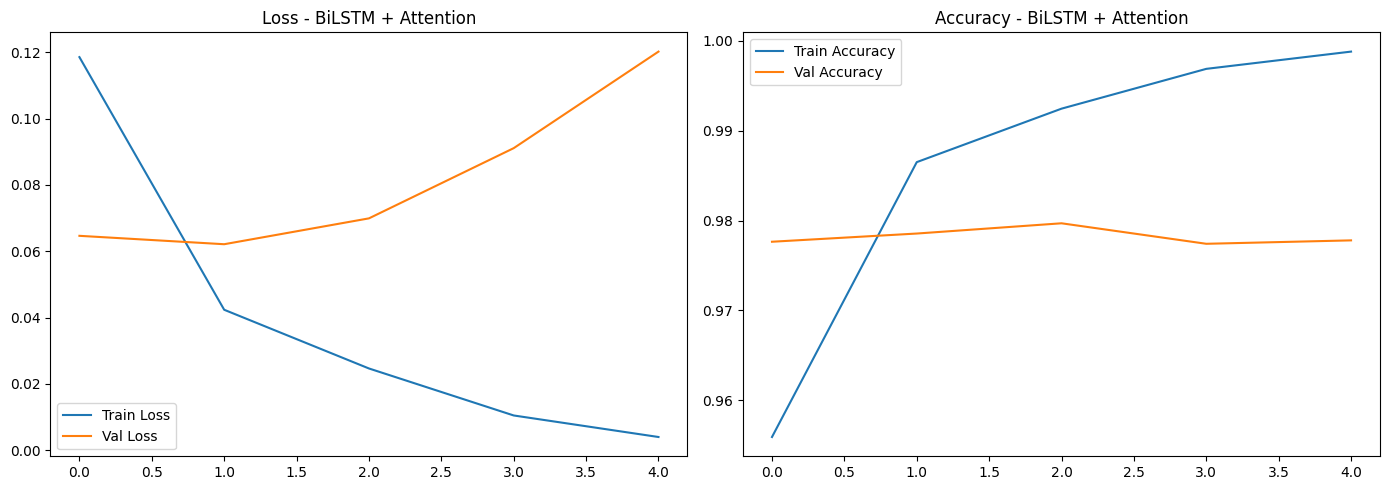

411/411 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step
              precision    recall  f1-score   support

       FAKTA       0.98      0.97      0.97      5525
       HOAKS       0.98      0.99      0.98      7622

    accuracy                           0.98     13147
   macro avg       0.98      0.98      0.98     13147
weighted avg       0.98      0.98      0.98     13147



In [105]:
# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['loss'], label='Train Loss')
ax1.plot(history['val_loss'], label='Val Loss')
ax1.set_title('Loss - BiLSTM + Attention')
ax1.legend()

ax2.plot(history['accuracy'], label='Train Accuracy')
ax2.plot(history['val_accuracy'], label='Val Accuracy')
ax2.set_title('Accuracy - BiLSTM + Attention')
ax2.legend()

plt.tight_layout()
plt.show()

# Classification Report
y_pred = (model.predict(X_test_pad) >= 0.5).astype(int)
print(classification_report(y_test, y_pred, target_names=['FAKTA', 'HOAKS']))

In [106]:
# Simpan Model
os.makedirs('/content/drive/MyDrive/fake-news-detection/models', exist_ok=True)
model.save('/content/drive/MyDrive/fake-news-detection/models/model_bilstm.keras')
print("✅ Model saved!")

✅ Model saved!
